In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
train_path = "train"
test_path = "test"

# Load and preprocess dataset
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_path,
    image_size=(28, 28),   # resize to MNIST-like dimensions if needed
    color_mode='grayscale',  # or 'rgb'
    batch_size=32,
    label_mode='int'
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_path,
    image_size=(28, 28),
    color_mode='grayscale',
    batch_size=32,
    label_mode='int'
)

Found 17000 files belonging to 10 classes.
Found 3001 files belonging to 10 classes.


In [4]:
def normalize_images(image, label):
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

train_ds = train_ds.map(normalize_images)
test_ds = test_ds.map(normalize_images)


In [5]:
cnn_model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    layers.MaxPooling2D(2,2),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')  # Change 10 → number of classes if different
])

cnn_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])



C:\Users\Ayush Raj\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [6]:
history = cnn_model.fit(train_ds, epochs=5, validation_data=test_ds)

Epoch 1/5
532/532 ━━━━━━━━━━━━━━━━━━━━ 56s 97ms/step - accuracy: 0.9311 - loss: 0.2254 - val_accuracy: 0.9820 - val_loss: 0.0525
Epoch 2/5
532/532 ━━━━━━━━━━━━━━━━━━━━ 53s 100ms/step - accuracy: 0.9872 - loss: 0.0418 - val_accuracy: 0.9883 - val_loss: 0.0409
Epoch 3/5
532/532 ━━━━━━━━━━━━━━━━━━━━ 54s 101ms/step - accuracy: 0.9938 - loss: 0.0225 - val_accuracy: 0.9843 - val_loss: 0.0583
Epoch 4/5
532/532 ━━━━━━━━━━━━━━━━━━━━ 52s 97ms/step - accuracy: 0.9958 - loss: 0.0162 - val_accuracy: 0.9923 - val_loss: 0.0329
Epoch 5/5
532/532 ━━━━━━━━━━━━━━━━━━━━ 54s 101ms/step - accuracy: 0.9953 - loss: 0.0143 - val_accuracy: 0.9920 - val_loss: 0.0305


94/94 ━━━━━━━━━━━━━━━━━━━━ 6s 66ms/step - accuracy: 0.9920 - loss: 0.0305

✅ CNN Test Accuracy: 99.20%


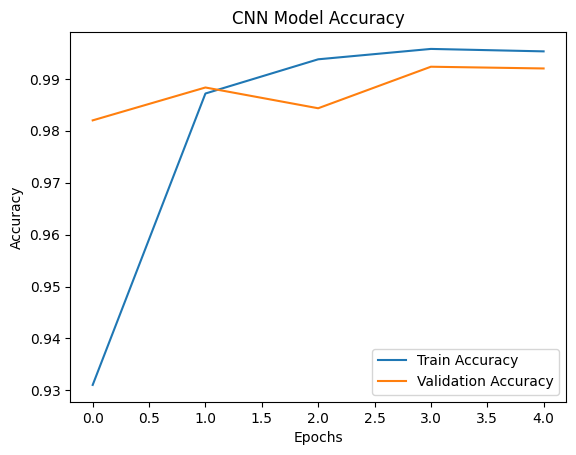

In [7]:
loss, acc = cnn_model.evaluate(test_ds)
print(f"\n✅ CNN Test Accuracy: {acc*100:.2f}%")

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('CNN Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [8]:
import random

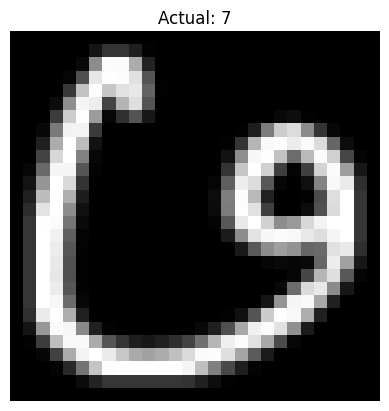

94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step
Handwritten number in the image is = 7


In [12]:
x_test = []
y_test = []

for images, labels in test_ds:
    x_test.append(images.numpy())
    y_test.append(labels.numpy())

x_test = np.vstack(x_test)  # shape: (num_samples, 28,28,1)
y_test = np.hstack(y_test)  # shape: (num_samples,)

# Pick a random image
n = random.randint(0, len(x_test)-1)

# Display the image
plt.imshow(x_test[n].reshape(28,28), cmap='gray')
plt.title(f"Actual: {y_test[n]}")
plt.axis('off')
plt.show()

# Predict on the entire test set
predicted_values = cnn_model.predict(x_test)

# Print predicted class for the random image
print("Handwritten number in the image is =", np.argmax(predicted_values[n]))

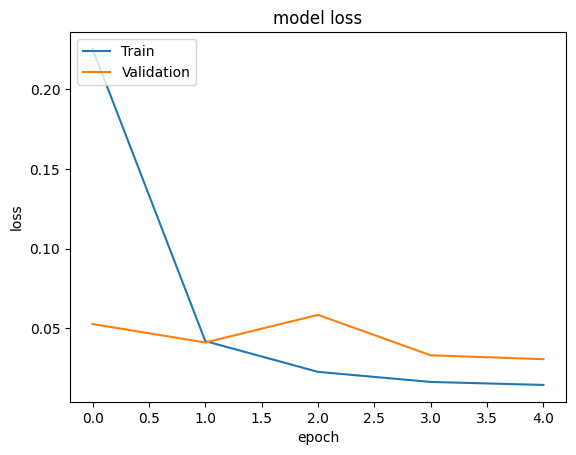

In [13]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()